In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import sys, os
sys.path.append(os.path.abspath('..'))
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import  TensorDataset, DataLoader

from config_mounir import FarOODFramework
from eval_functions import train, auc_and_fpr_recall, visualize, calc_outputs_test, calc_correlations, separabilite
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"
torch.cuda.is_available()

True

In [ ]:
seed = 42  
torch.manual_seed(seed)
np.random.seed(seed)

torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Préparation des données

(Cas simple: **Far OOD, 2 modalités** (video, flow))

Chaque donnée sera représentée par la valeur de la MSP du modèle dans les 4 cas.
- Pour chaque donnée:
    - Pour chaque cas (modalité)
        - Prendre la MSP 

-> Chaque donnée sera représentée par un vecteur de 4 dimensions

Prendre les fichiers conf et les stacker

Stacker verticalement les différents datasets puis stacker horizontalement les dimensions


In [2]:
root_dir = "/data/maouche/MultiOOD/HMDB-rgb-flow/saved_files/"
ood_datasets = ['UCF', 'EPIC', 'HAC']
modalities = ['video', 'flow']

## Création des datasets

Données ID (HMDB)

In [3]:
template_id_sans_react =  "id_HMDB_conf_baseline_best_val.npy"
template_id_react_tout = "id_HMDB_conf_baseline_best_react_val.npy"
template_id_par_modalite = "id_HMDB_conf_baseline_best_react_{}_val.npy"

# Sans react
conf_sans_react = np.load(root_dir+template_id_sans_react)
conf_sans_react = conf_sans_react.reshape(conf_sans_react.shape[0], 1)

# React sur tout
conf_react_tout = np.load(root_dir+template_id_react_tout)
conf_react_tout = conf_react_tout.reshape(conf_react_tout.shape[0], 1)


# React par modalité
conf_une_modalite = []
for modality in modalities:
    x = np.load(root_dir+template_id_par_modalite.format(modality))
    x = x.reshape(x.shape[0], 1)
    conf_une_modalite.append(x)
conf_une_modalite = np.hstack(conf_une_modalite)


dataset_id = np.hstack([conf_sans_react, conf_react_tout, conf_une_modalite]) #(N,4)

Données OOD

In [ ]:
template_sans_react =  "id_HMDB_ood_{}_conf_baseline_best_eval.npy"
template_react_tout = "id_HMDB_ood_{}_conf_baseline_best_react_eval.npy"
template_par_modalite = "id_HMDB_ood_{}_conf_baseline_best_react_{}_eval.npy"

# Sans react
conf_sans_react = []
for dataset in ood_datasets:
    x = np.load(root_dir+template_sans_react.format(dataset))
    x = x.reshape(x.shape[0], 1)
    conf_sans_react.append(x)
conf_sans_react = np.vstack(conf_sans_react) #(N,1), avec N = 9603, toutes les vidéos des 3 datasets (selon les filtrages far ood)

# React sur tout 
conf_react_tout = []
for dataset in ood_datasets:
    x = np.load(root_dir+template_react_tout.format(dataset))
    x = x.reshape(x.shape[0], 1)
    conf_react_tout.append(x)
conf_react_tout = np.vstack(conf_react_tout) #(N,1)

# React par modalité
conf_par_modalite = []
for modality in modalities:
    conf_une_modalite = []
    for dataset in ood_datasets:
        x = np.load(root_dir+template_par_modalite.format(dataset, modality))
        x = x.reshape(x.shape[0], 1)
        conf_une_modalite.append(x)
    conf_une_modalite = np.vstack(conf_une_modalite)
    conf_par_modalite.append(conf_une_modalite)

conf_par_modalite = np.reshape(conf_par_modalite, (-1, len(modalities)))  #(N,1)

dataset_ood = np.hstack([conf_sans_react, conf_react_tout, conf_par_modalite]) #(N,4)

In [12]:
X = np.vstack([dataset_id, dataset_ood])

Création des labels

In [ ]:
y_id = np.ones(dataset_id.shape[0])
y_id = y_id.reshape(y_id.shape[0], 1)

y_ood = np.zeros(dataset_ood.shape[0])
y_ood = y_ood.reshape(y_ood.shape[0], 1)

Y = np.vstack([y_id, y_ood])

X.shape, Y.shape

((10446, 4), (10446, 1))

## Création des dataloaders

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
                X, Y, stratify=Y, test_size=0.2, random_state=42)

data = {"X_train":X_train, "y_train": y_train, "X_test": X_test, "y_test": y_test}

In [ ]:
with open("data_vf.pkl", 'wb') as f:
    pickle.dump(data, f)

# Chargement des données

In [2]:
with open('data_vf.pkl', 'rb') as f:
    data = pickle.load(f)

In [3]:
X_tensor_train = torch.tensor(data['X_train'], dtype=torch.float32)
y_tensor_train = torch.tensor(data['y_train'], dtype=torch.float32)
y_tensor_train = 1-y_tensor_train # Transformer les labels en 0:ID, 1:OOD
train_dataset = TensorDataset(X_tensor_train, y_tensor_train)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
print(len(X_tensor_train), "elements", np.unique(y_tensor_train, return_counts=True))
# On a beaucoup de OOD car on a pris 3 datasets contre 1 pour ID 

8356 elements (array([0., 1.], dtype=float32), array([ 674, 7682]))


In [4]:
X_tensor_test = torch.tensor(data['X_test'], dtype=torch.float32)
y_tensor_test = torch.tensor(data['y_test'], dtype=torch.float32)
y_tensor_test = 1-y_tensor_test# pour classification binaire
test_dataset = TensorDataset(X_tensor_test, y_tensor_test)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=True)
print(len(X_tensor_test), "elements", np.unique(y_tensor_test, return_counts=True))

2090 elements (array([0., 1.], dtype=float32), array([ 169, 1921]))


# Modèle

In [5]:
# Calcul des poids des classes
unique_values, counts = np.unique(y_tensor_train, return_counts=True) ### Entrainement avec pondération
#ratio = counts/np.sum(counts)
pos_weight = counts[0] / counts[1] # N_negative / N_positive
pos_weight

0.08773756834157771

In [23]:
num_positives = torch.sum(y_tensor_train, dim=0)
num_negatives = len(y_tensor_train) - num_positives
pos_weight  = num_negatives / num_positives
pos_weight

tensor([0.0877])

In [ ]:
input_dim = 4 #react sur tous + react sur aucun + react video + react flow
output_dim = 1
model = nn.Linear(input_dim, output_dim)

criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)) # Pondération des classes
lr=0.1
optim = torch.optim.SGD(model.parameters(), lr)
nb_epochs = 50

C:\Users\mouni\AppData\Local\Temp\ipykernel_24044\1424558274.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)) # Pondération des classes


# Entrainement

In [ ]:
plot_loss = []
plot_acc = []

for _ in range(nb_epochs):
    loss_values = []
    acc_values = []
    for i, (batch_X, batch_y) in enumerate(train_dataloader):
        outputs = model(batch_X) # Retourne l'output du module linéaire. Il faut faire passer par sigmoide
        
        #preds = np.where(nn.functional.sigmoid(outputs).detach().numpy()>0.5
        #                , 1, 0)
        logits = nn.functional.sigmoid(outputs)
        preds = (logits > 0.5).int()    
        acc = (preds == batch_y).float().mean().item()

        #acc = np.sum((batch_y.numpy() == preds)) / batch_y.shape[0]
        acc_values.append(acc)
        
        loss = criterion(outputs, batch_y)
        loss_values.append(loss.item())

        optim.zero_grad()
        loss.backward()
        optim.step()
    plot_loss.append(np.mean(loss_values))
    plot_acc.append(np.mean(acc_values))

accuracy_train = np.mean(plot_acc)
print("accuracy train: ", accuracy_train)

accuracy train:  0.8391770038167939


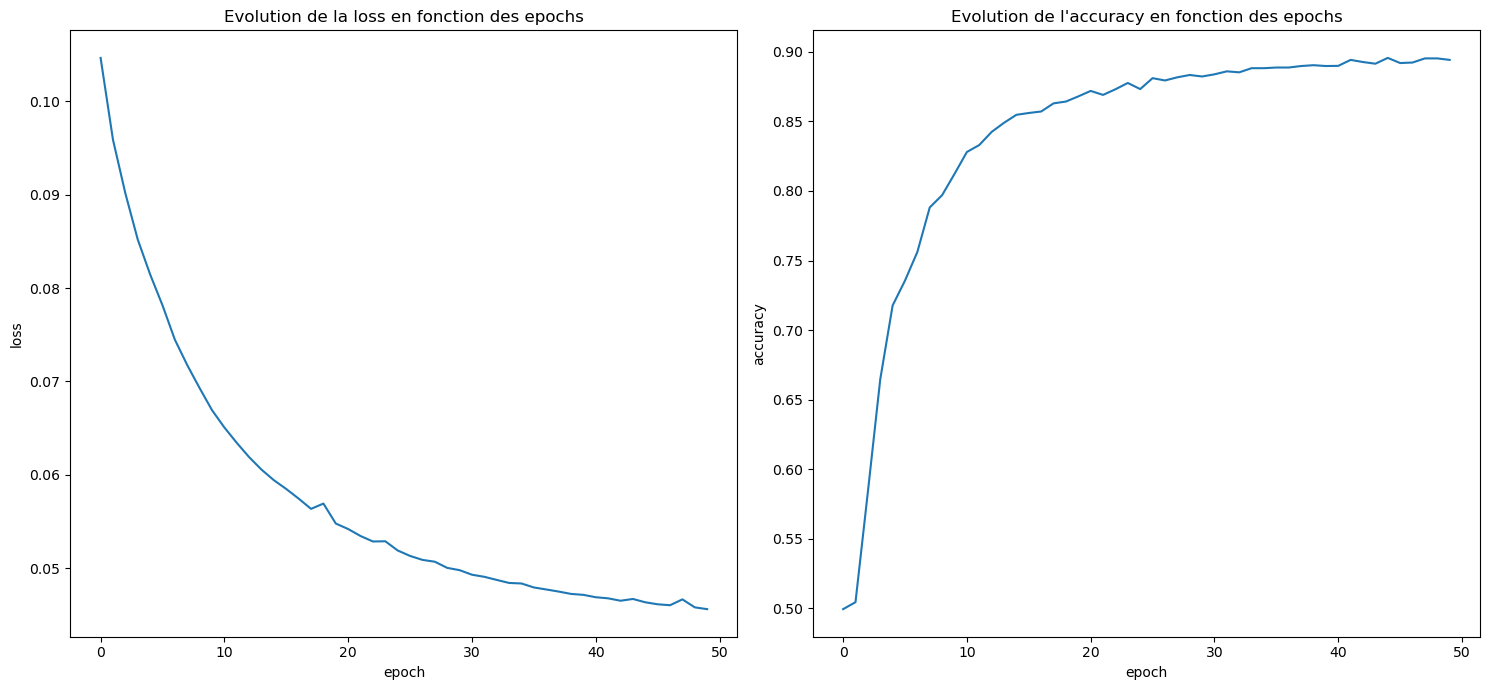

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(15, 7))

ax[0].plot(np.arange(len(plot_loss)), plot_loss)
ax[0].set_xlabel("epoch")
ax[0].set_ylabel("loss")
ax[0].set_title("Evolution de la loss en fonction des epochs")

ax[1].plot(np.arange(len(plot_acc)), plot_acc)
ax[1].set_xlabel("epoch")
ax[1].set_ylabel("accuracy")
ax[1].set_title("Evolution de l'accuracy en fonction des epochs")

plt.tight_layout()
plt.show()


In [ ]:
torch.save(model.state_dict(), "model_vf.pth")

In [ ]:
for name, param in model.named_parameters():
    print(f"{name}")
    print(param.data)
poids = dict(model.named_parameters())["weight"].detach().numpy().squeeze().round(4)

weight
tensor([[-1.6564, -1.9537, -2.4476, -2.4168]])
bias
tensor([6.2427])


In [13]:
input_dim = 4 #react sur tous + react sur aucun + react video + react flow + react audio
output_dim = 1
model = nn.Linear(input_dim, output_dim)

model.load_state_dict(torch.load("model_vf.pth"))

<All keys matched successfully>

# Tests

### Séparabilité

In [ ]:
all_outputs_test = []
all_labels_test = []

for batch_X, batch_y in test_dataloader:
    with torch.no_grad():
        outputs = nn.functional.sigmoid(model(batch_X))
    
    all_outputs_test += [x.item() for x in outputs]
    all_labels_test += [x.item() for x in batch_y]
    
logits_id_test = []
logits_ood_test = []

for value, label in list(zip(all_outputs_test, all_labels_test)):
    if label == 1:
        logits_ood_test.append(value)
    else:
        logits_id_test.append(value)
        
outputs_test = {"all_labels_test": all_labels_test,
            "all_outputs_test": all_outputs_test,
            "logits_id_test": logits_id_test,
            "logits_ood_test": logits_ood_test}

# with open("outputs_test_vf.pkl", 'wb') as f:
#     pickle.dump(outputs_test, f)

In [ ]:
with open("outputs_test_vf.pkl", 'rb') as f:
    outputs_test = pickle.load(f)

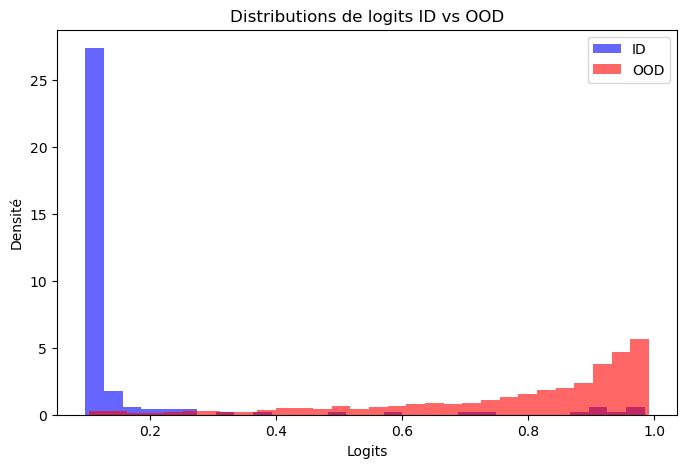

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(outputs_test["logits_id_test"], bins=30, alpha=0.6, label="ID", color='blue', density=True)
plt.hist(outputs_test["logits_ood_test"], bins=30, alpha=0.6, label="OOD", color='red', density=True)

plt.xlabel("Logits")
plt.ylabel("Densité")
plt.title("Distributions de logits ID vs OOD")
plt.legend()
plt.show()


### AUC & FPR

In [ ]:
auroc, aupr_in, aupr_out, fpr = auc_and_fpr_recall(np.array(outputs_test["all_outputs_test"]), np.array(outputs_test["all_labels_test"]), tpr_th=0.95)
auroc, fpr

(0.9583550234252993, 0.07692307692307693)

## Corrélation

In [3]:
poids = [-1.6564, -1.9537, -2.4476, -2.4168] #sans, tout, video, flux
df, correlation_id, correlation_ood = calc_correlations(FarOODFramework(), "react", poids)
print("Correlation ID : ", correlation_id)
print("Correlation OOD : ", correlation_ood)
df

Correlation ID :  0.7915379159538463
Correlation OOD :  0.9764584463454885


,config,tout,video,flow
0,poids_far_ood,-1.953700,-2.447600,-2.416800
1,perturbation_far_ood_id,0.008893,0.006114,0.002462
2,perturbation_far_ood_ood,0.029869,0.016096,0.013231


# Modèle 2 Couches

In [ ]:
input_dim = 4 #react sur tous + react sur aucun + react video + react flow + react audio
hidden_dim = 2
output_dim = 1
model = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, output_dim))
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)) # Pondération des classes
lr=0.1
optim = torch.optim.SGD(model.parameters(), lr)
nb_epochs = 100

cuda
accuracy train:  0.9526479007633588


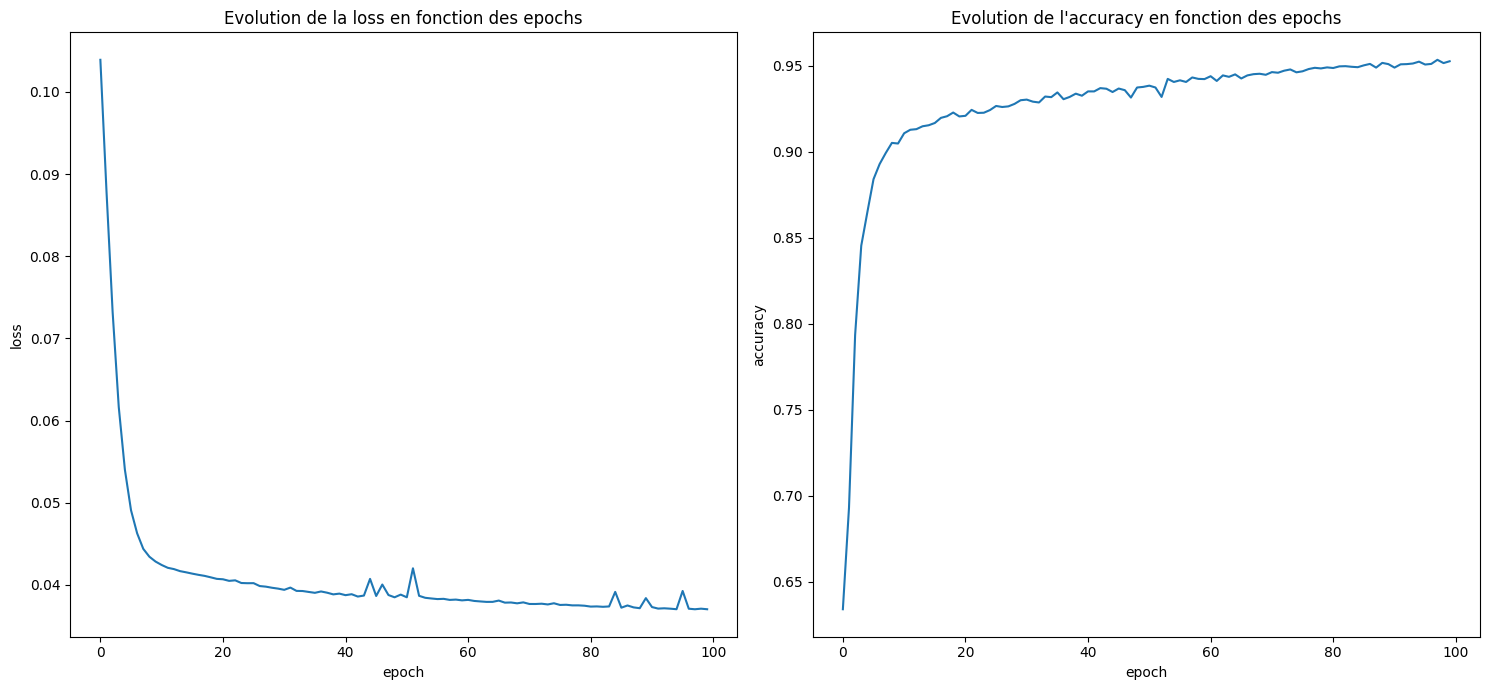

In [ ]:
plot_loss, plot_acc, accuracy_train = train(model, train_dataloader, criterion, optim, nb_epochs)
visualize(plot_loss, plot_acc)

In [ ]:
torch.save(model.state_dict(), "model_vf_2c.pth")

## Tests

In [ ]:
input_dim = 4 #react sur tous + react sur aucun + react video + react flow + react audio
hidden_dim = 2
output_dim = 1
model = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, output_dim))

model.load_state_dict(torch.load("model_vf_2c.pth"))

Séparabilité

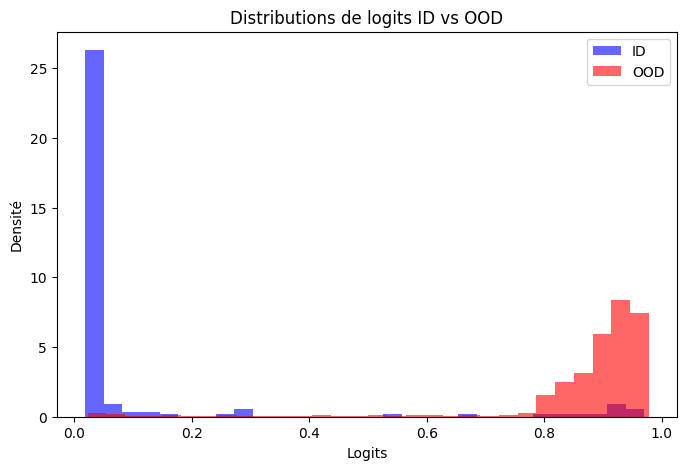

In [9]:
outputs_test = calc_outputs_test(model, test_dataloader)
separabilite(outputs_test)

AUC et FPR

In [11]:
auroc, aupr_in, aupr_out, fpr = auc_and_fpr_recall(np.array(outputs_test["all_outputs_test"]), np.array(outputs_test["all_labels_test"]), tpr_th=0.95)
auroc, fpr

(0.958410467920739, 0.07692307692307693)